## Pandas Groupby with Hurricane Data

In [1]:
import pandas as pd
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv'
df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})
df.tail()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
716160,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 06:00:00,NR,23.0325,89.3509,NaN,NaN
716161,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 09:00:00,NR,23.3337,89.6178,NaN,NaN
716162,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 12:00:00,NR,23.6263,89.8799,NaN,NaN
716163,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 15:00:00,NR,23.9143,90.1400,NaN,NaN
716164,2024147N19089,2024,27,NI,BB,REMAL,2024-05-27 18:00:00,NR,24.2000,90.4000,NaN,NaN


In [2]:
len(df)

716165

In [3]:
na_rows = (df["BASIN"] == "NA").sum()
na_unique_hurricanes = df.loc[df["BASIN"] == "NA", "SID"].nunique()

na_rows, na_unique_hurricanes

(126392, 2344)

In [4]:
df["BASIN"].unique()

array(['NI', 'SI', 'NA', 'EP', 'WP', 'SP', 'SA'], dtype=object)

In [6]:
df["SUBBASIN"].unique()

array(['BB', 'AS', 'MM', 'GM', 'NA', 'CS', 'WA', 'EA', 'CP'], dtype=object)

In [7]:
df["NATURE"].unique()

array(['NR', 'TS', 'ET', 'SS', 'MX', 'DS'], dtype=object)

In [8]:
sorted(df["BASIN"].unique())
sorted(df["SUBBASIN"].unique())
sorted(df["NATURE"].unique())

['DS', 'ET', 'MX', 'NR', 'SS', 'TS']

In [9]:
df = df.rename(columns={"WMO_WIND": "WIND", "WMO_PRES": "PRES"})
df.columns

Index(['SID', 'SEASON', 'NUMBER', 'BASIN', 'SUBBASIN', 'NAME', 'ISO_TIME',
       'NATURE', 'LAT', 'LON', 'WIND', 'PRES'],
      dtype='object')

In [10]:
df[["WIND", "PRES"]].head()

,WIND,PRES
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [11]:
top10_rows = df.nlargest(10, "WIND")
top10_rows

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
666142,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 12:00:00,TS,17.3,-105.6,185.0,872.0
666140,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 06:00:00,TS,16.5,-105.4,180.0,886.0
666144,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 18:00:00,TS,18.3,-105.3,180.0,878.0
427655,1980214N11330,1980,57,NA,GM,ALLEN,1980-08-07 18:00:00,TS,21.8,-86.4,165.0,899.0
178210,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 00:00:00,TS,24.6,-80.5,160.0,892.0
178211,1935241N23291,1935,46,NA,NA,NaN,1935-09-03 02:00:00,TS,24.8,-80.8,160.0,892.0
178213,1935241N23291,1935,46,NA,GM,NaN,1935-09-03 06:00:00,TS,25.1,-81.1,160.0,NaN
482093,1988253N12306,1988,74,NA,CS,GILBERT,1988-09-14 00:00:00,TS,19.7,-83.8,160.0,888.0
552477,1997253N12255,1997,81,EP,MM,LINDA,1997-09-12 06:00:00,TS,17.1,-109.6,160.0,902.0
605764,2005289N18282,2005,97,NA,CS,WILMA,2005-10-19 12:00:00,TS,17.3,-82.8,160.0,882.0


In [12]:
top10_rows[["NAME", "BASIN", "ISO_TIME", "WIND", "PRES"]]

,NAME,BASIN,ISO_TIME,WIND,PRES
666142,PATRICIA,EP,2015-10-23 12:00:00,185.0,872.0
666140,PATRICIA,EP,2015-10-23 06:00:00,180.0,886.0
666144,PATRICIA,EP,2015-10-23 18:00:00,180.0,878.0
427655,ALLEN,NA,1980-08-07 18:00:00,165.0,899.0
178210,NaN,NA,1935-09-03 00:00:00,160.0,892.0
178211,NaN,NA,1935-09-03 02:00:00,160.0,892.0
178213,NaN,NA,1935-09-03 06:00:00,160.0,NaN
482093,GILBERT,NA,1988-09-14 00:00:00,160.0,888.0
552477,LINDA,EP,1997-09-12 06:00:00,160.0,902.0
605764,WILMA,NA,2005-10-19 12:00:00,160.0,882.0


In [13]:
top10_storm_wind = df.groupby("SID")["WIND"].max().nlargest(10)
top10_storm_wind

SID
2015293N13266    185.0
1980214N11330    165.0
1935241N23291    160.0
1988253N12306    160.0
1997253N12255    160.0
2005289N18282    160.0
2019236N10314    160.0
1998295N12284    155.0
2005261N21290    155.0
2009288N07267    155.0
Name: WIND, dtype: float64

In [18]:

df_valid = df.dropna(subset=["WIND"])

peak_wind = df_valid.groupby("SID", as_index=False)["WIND"].max()

name_map = df_valid.groupby("SID", as_index=False)["NAME"].first()

storm_peaks = peak_wind.merge(name_map, on="SID", how="left")

top20 = storm_peaks.nlargest(20, "WIND")[["NAME", "SID", "WIND"]]
top20

,NAME,SID,WIND
5247,PATRICIA,2015293N13266,185.0
1982,ALLEN,1980214N11330,165.0
655,None,1935241N23291,160.0
2710,GILBERT,1988253N12306,160.0
3593,LINDA,1997253N12255,160.0
4341,WILMA,2005289N18282,160.0
5607,DORIAN,2019236N10314,160.0
3690,MITCH,1998295N12284,155.0
4327,RITA,2005261N21290,155.0
4705,RICK,2009288N07267,155.0


In [20]:
import matplotlib.pyplot as plt

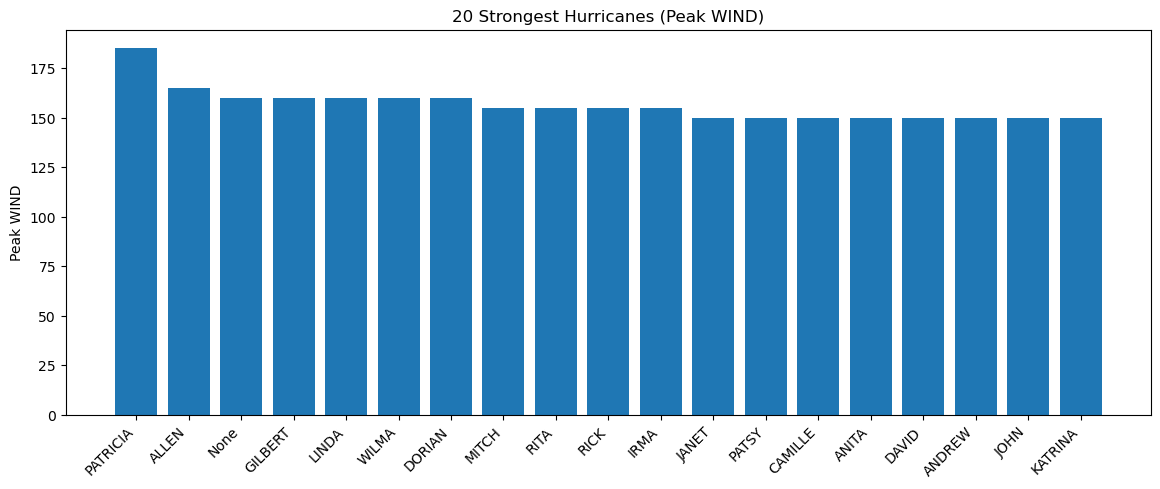

In [22]:
plt.figure(figsize=(14,5))
plt.bar(top20["NAME"].astype(str), top20["WIND"])
plt.ylabel("Peak WIND")
plt.title("20 Strongest Hurricanes (Peak WIND)")
plt.xticks(rotation=45, ha="right")
plt.show()

In [23]:
basin_counts = df["BASIN"].value_counts()
basin_counts

BASIN
WP    238485
SI    163710
NA    126392
SP     68233
EP     63434
NI     55792
SA       119
Name: count, dtype: int64

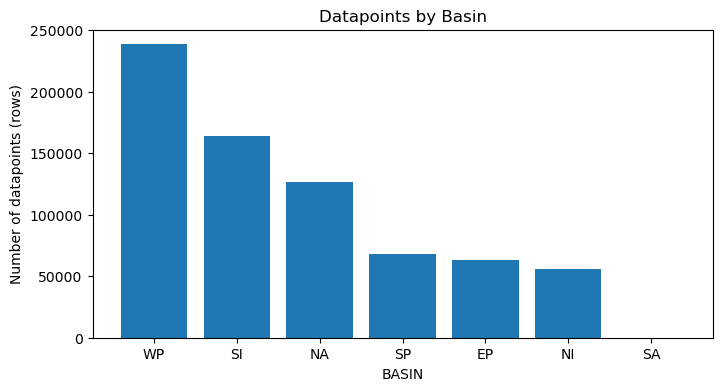

In [24]:
plt.figure(figsize=(8,4))
plt.bar(basin_counts.index, basin_counts.values)
plt.xlabel("BASIN")
plt.ylabel("Number of datapoints (rows)")
plt.title("Datapoints by Basin")
plt.show()

In [25]:
unique_by_basin = df.groupby("BASIN")["SID"].nunique()
unique_by_basin

BASIN
EP    1657
NA    2344
NI    1785
SA       3
SI    3061
SP    1321
WP    4289
Name: SID, dtype: int64

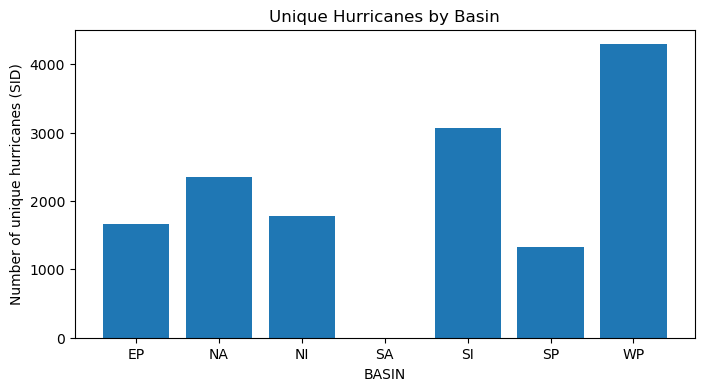

In [26]:
plt.figure(figsize=(8,4))
plt.bar(unique_by_basin.index, unique_by_basin.values)
plt.xlabel("BASIN")
plt.ylabel("Number of unique hurricanes (SID)")
plt.title("Unique Hurricanes by Basin")
plt.show()

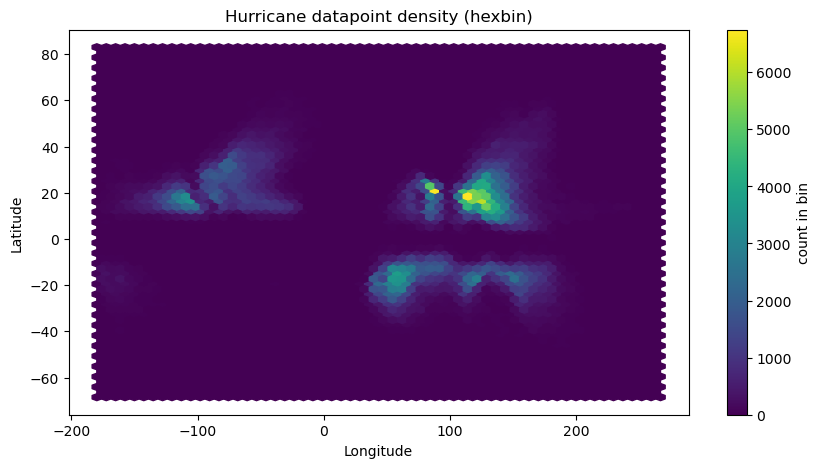

In [27]:
plt.figure(figsize=(10,5))
hb = plt.hexbin(df["LON"], df["LAT"], gridsize=60)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Hurricane datapoint density (hexbin)")
plt.colorbar(hb, label="count in bin")
plt.show()

In [28]:
katrina_2005 = df[(df["NAME"] == "KATRINA") & (df["ISO_TIME"].dt.year == 2005)]
katrina_2005[["SID", "NAME", "ISO_TIME", "LAT", "LON", "WIND"]].head()

,SID,NAME,ISO_TIME,LAT,LON,WIND
603763,2005236N23285,KATRINA,2005-08-23 18:00:00,23.1000,-75.1000,30.0
603764,2005236N23285,KATRINA,2005-08-23 21:00:00,23.2476,-75.4049,NaN
603765,2005236N23285,KATRINA,2005-08-24 00:00:00,23.4000,-75.7000,30.0
603766,2005236N23285,KATRINA,2005-08-24 03:00:00,23.5700,-75.9726,NaN
603767,2005236N23285,KATRINA,2005-08-24 06:00:00,23.8000,-76.2000,30.0


In [29]:
katrina_2005["SID"].unique()

array(['2005236N23285'], dtype=object)

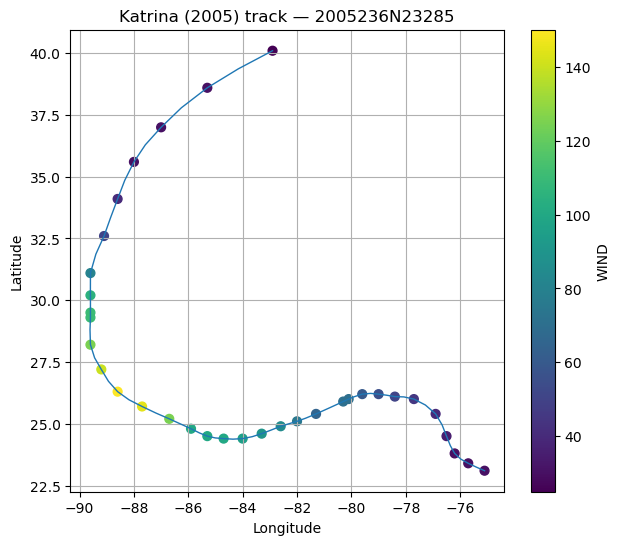

In [30]:
katrina_sid = katrina_2005["SID"].iloc[0]
katrina = df[df["SID"] == katrina_sid].sort_values("ISO_TIME")

plt.figure(figsize=(7,6))
sc = plt.scatter(katrina["LON"], katrina["LAT"], c=katrina["WIND"], s=40)
plt.plot(katrina["LON"], katrina["LAT"], linewidth=1)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Katrina (2005) track — {katrina_sid}")
plt.colorbar(sc, label="WIND")
plt.grid(True)
plt.show()

In [31]:
df = df.set_index("ISO_TIME")
df.index

DatetimeIndex(['1842-10-25 03:00:00', '1842-10-25 06:00:00',
               '1842-10-25 09:00:00', '1842-10-25 12:00:00',
               '1842-10-25 15:00:00', '1842-10-25 18:00:00',
               '1842-10-25 21:00:00', '1842-10-26 00:00:00',
               '1842-10-26 03:00:00', '1842-10-26 06:00:00',
               ...
               '2024-05-26 15:00:00', '2024-05-26 18:00:00',
               '2024-05-26 21:00:00', '2024-05-27 00:00:00',
               '2024-05-27 03:00:00', '2024-05-27 06:00:00',
               '2024-05-27 09:00:00', '2024-05-27 12:00:00',
               '2024-05-27 15:00:00', '2024-05-27 18:00:00'],
              dtype='datetime64[ns]', name='ISO_TIME', length=716165, freq=None)

In [32]:
counts_per_year = df["SID"].resample("1Y").count()
counts_per_year.head(), counts_per_year.tail()

/tmp/ipykernel_420263/1008179486.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  counts_per_year = df["SID"].resample("1Y").count()


(ISO_TIME
 1842-12-31    65
 1843-12-31     0
 1844-12-31     0
 1845-12-31    25
 1846-12-31     0
 Freq: YE-DEC, Name: SID, dtype: int64,
 ISO_TIME
 2020-12-31    6407
 2021-12-31    6493
 2022-12-31    4439
 2023-12-31    4720
 2024-12-31     899
 Freq: YE-DEC, Name: SID, dtype: int64)

In [33]:
counts_per_year.sort_values(ascending=False).head(10)

ISO_TIME
1996-12-31    9189
1971-12-31    8911
1997-12-31    8854
1972-12-31    8503
1992-12-31    8389
1970-12-31    8295
1994-12-31    8271
1990-12-31    7996
1967-12-31    7934
2018-12-31    7763
Name: SID, dtype: int64

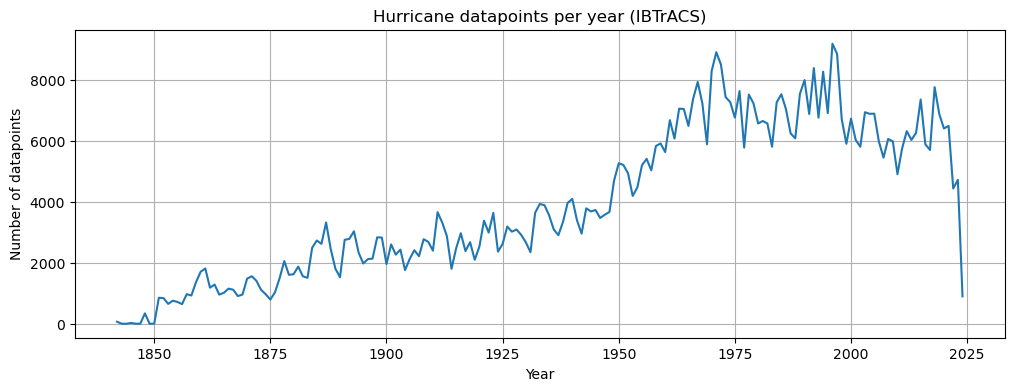

In [34]:
plt.figure(figsize=(12,4))
plt.plot(counts_per_year.index.year, counts_per_year.values)
plt.xlabel("Year")
plt.ylabel("Number of datapoints")
plt.title("Hurricane datapoints per year (IBTrACS)")
plt.grid(True)
plt.show()

#### The number of hurricane datapoints per year increases strongly over time. Early years (mid-1800s to early 1900s) have very low counts, which is likely due to sparse historical observations and incomplete reporting—storms were only recorded when they impacted ships or coastlines. Counts rise through the 20th century and jump sharply in the mid-to-late 1900s, consistent with improved observing systems (aircraft reconnaissance and especially satellites) and more consistent global tracking, which produces many more recorded positions per storm. In the “top 10” years, peaks occur around the late 1960s–1990s (e.g., 1971–72 and 1996–97), reflecting either very active storm years and/or denser observational sampling per storm (more frequent position fixes). The sharp drop at the end (e.g., 2024 showing a much smaller count) is most likely because the dataset is incomplete for that year (partial year available), not because hurricanes suddenly disappeared.